In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import config, jit, random, grad, vmap, flatten_util, hessian
from jax_md.quantity import force
from jax import random

from scipy import integrate

from thermo_oscillator_network_fns import energy_network

from scipy.stats import multivariate_normal

import os

import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


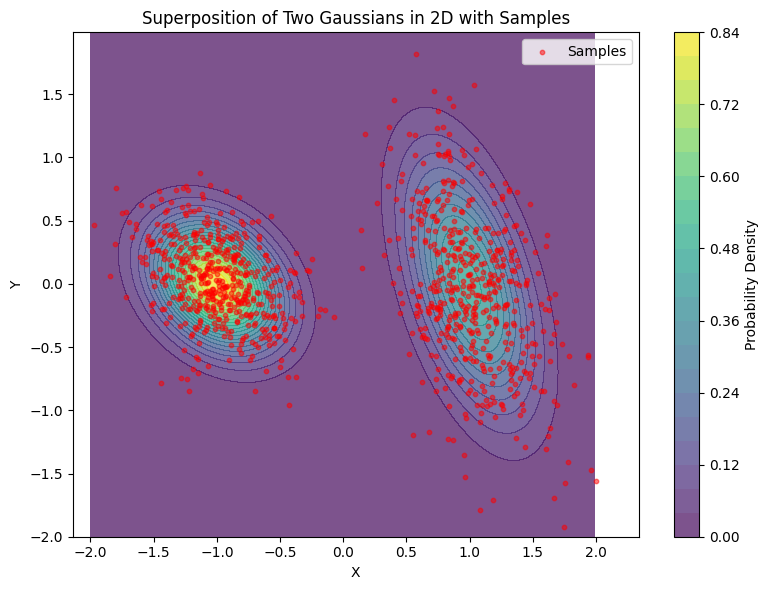

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([1, 0])
sigma1 = jnp.array([[0.1, -0.1], [-0.1, 0.4]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = 0.5

# Number of samples to generate
n_samples = 1000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [3]:
# Duffing params
k_lin= jnp.array([-.1, 0.1])
k_duff = jnp.array([.5, .0])
c_lin = jnp.array([.0])
c_optomech = jnp.array([.0])
connectivity = jnp.array([[0, 1]])

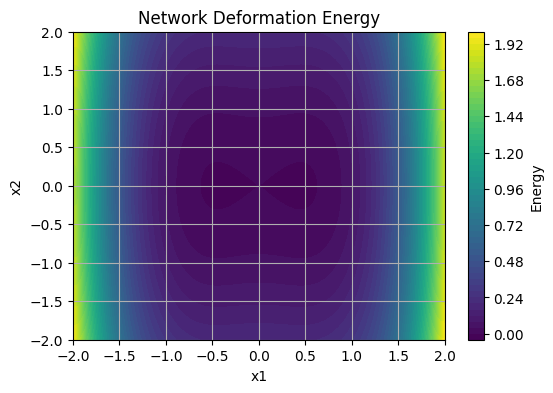

In [4]:
# Plot Network Deformation Energy
x1_values = jnp.linspace(-x_lim, x_lim, 100)
x2_values = jnp.linspace(-y_lim, y_lim, 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

energy_values = vmap(lambda x1, x2: energy_network(jnp.array([x1, x2]).T, k_lin, k_duff, c_lin, c_optomech, connectivity))(X1.ravel(), X2.ravel())
energy_values = energy_values.reshape(X1.shape)

plt.figure(figsize=(6, 4))
contour = plt.contourf(X1, X2, energy_values, levels=50, cmap='viridis')
plt.colorbar(contour, label='Energy')
plt.title("Network Deformation Energy")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

In [5]:

def loss_fn(k_lin, k_duff, c_lin, c_optomech):
    # Redefine network_deformation_energy with current k1 and k2
    def current_network_energy(x):
        return energy_network(x, k_lin, k_duff, c_lin, c_optomech, connectivity)
    
    # Recompute score and score2 with current energy function
    current_score = grad(current_network_energy)
    current_score2 = hessian(current_network_energy)
    
    # Recompute score_loss_per_sample with current score and score2
    current_score_loss_per_sample = lambda x: (-jnp.trace(current_score2(x)) + 1/2 * jnp.sum(current_score(x)**2))/n_samples   
    # Compute total loss
    return jnp.sum(vmap(current_score_loss_per_sample)(samples))

# Compute gradients of the loss with respect to k1 and k2
@jit
def grad_loss(k_lin, k_duff, c_lin, c_optomech):
    return grad(loss_fn, argnums=(0, 1, 2, 3))(k_lin, k_duff, c_lin, c_optomech)


In [6]:
# Optimization parameters
learning_rate = 0.01
num_iterations = 6000

# Initial values for k1 and k2
k_lin_opt = k_lin
k_duff_opt = k_duff
c_lin_opt = c_lin
c_optomech_opt = c_optomech

design_mask = jnp.array([1, 1, 1, 1])

# List to store loss values
loss_values = []

# Optimization loop
for i in range(num_iterations+1):
    # Compute gradients
    grads = grad_loss(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
    
    # Update k1 and k2
    k_lin_opt = k_lin_opt - learning_rate * grads[0]*design_mask[0]
    k_duff_opt = k_duff_opt - learning_rate * grads[1]*design_mask[1]
    c_lin_opt = c_lin_opt - learning_rate * grads[2]*design_mask[2]
    c_optomech_opt = c_optomech_opt - learning_rate * grads[3]*design_mask[3]
    
    # Save and print progress every 100 iterations
    if i % 100 == 0:
        current_loss = loss_fn(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
        loss_values.append(current_loss)
        print(f"Iteration {i}, Loss: {current_loss}, k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")

Iteration 0, Loss: -1.4441659450531006, k_lin: [-0.09731608  0.10976293], k_duff: [0.51918495 0.00687958], c_lin: [0.0221274], c_optomech: [0.00024798]
Iteration 100, Loss: -3.081542730331421, k_lin: [-0.4681182   0.90038496], k_duff: [1.196093  0.4673926], c_lin: [-0.02799907], c_optomech: [-0.04148986]
Iteration 200, Loss: -3.851713180541992, k_lin: [-0.872228   1.5346876], k_duff: [1.5546896  0.71348995], c_lin: [-0.11328235], c_optomech: [-0.09662952]
Iteration 300, Loss: -4.322419166564941, k_lin: [-1.2171397  2.0489604], k_duff: [1.8208729 0.8139718], c_lin: [-0.16459374], c_optomech: [-0.13486639]
Iteration 400, Loss: -4.634641647338867, k_lin: [-1.5062866  2.4754303], k_duff: [2.030436   0.82115704], c_lin: [-0.19870734], c_optomech: [-0.15849572]
Iteration 500, Loss: -4.856460094451904, k_lin: [-1.7484457  2.8374834], k_duff: [2.1986756 0.770803 ], c_lin: [-0.22217652], c_optomech: [-0.17228626]
Iteration 600, Loss: -5.022525787353516, k_lin: [-1.951432   3.1512954], k_duff: [

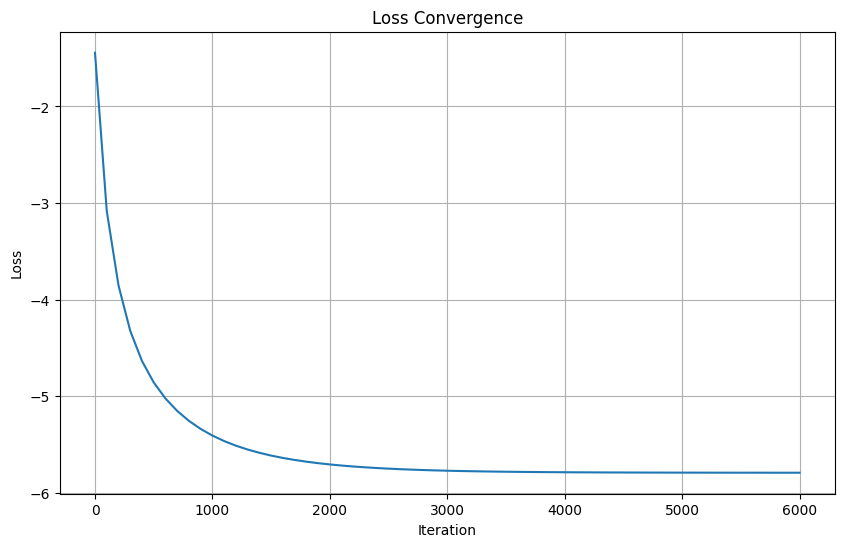

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(0, num_iterations+1, 100), loss_values)
plt.title('Loss Convergence')
plt.xlabel('Iteration')
plt.ylabel('Loss')
# plt.yscale('log')  # Use log scale for y-axis to better visualize the convergence
plt.grid(True)

# Create a descriptive filename
folder_filename = f"2d_mu1_{mu1[0]:.1f}_{mu1[1]:.1f}_mu2_{mu2[0]:.1f}_{mu2[1]:.1f}_"
convergence_filename = f"k_lin_init_{k_lin[0]:.2f}_{k_lin[1]:.2f}_k_lin_final_{k_lin_opt[0]:.2f}_{k_lin_opt[1]:.2f}_"
convergence_filename += f"k_duff_init_{k_duff[0]:.2f}_{k_duff[1]:.2f}_k_duff_final_{k_duff_opt[0]:.2f}_{k_duff_opt[1]:.2f}_"
convergence_filename += f"c_lin_init_{c_lin[0]:.2f}_c_lin_final_{c_lin_opt[0]:.2f}_"
convergence_filename += f"c_optomech_init_{c_optomech[0]:.2f}_c_optomech_final_{c_optomech_opt[0]:.2f}_"
convergence_filename += f"numSamples_{n_samples}_numIterations_{num_iterations}_finalLoss_{loss_values[-1]:.2f}_convergence.png"

# Create the folder if it doesn't exist
folder_path = f'results/{folder_filename}'
os.makedirs(folder_path, exist_ok=True)

# Save the figure
plt.savefig(f'{folder_path}/{convergence_filename}', dpi=300, bbox_inches='tight')

# Show the plot (optional, you can comment this out if you don't need to display it)
plt.show()



In [9]:
# Plot Network Deformation Energy for original and optimized k values, and distribution with samples
x1_values = jnp.linspace(-x_lim, x_lim, 100)
x2_values = jnp.linspace(-y_lim, y_lim, 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original k
energy_values_original = vmap(lambda x1, x2: energy_network(jnp.array([x1, x2]).T, k_lin, k_duff, c_lin, c_optomech, connectivity))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate energy values for optimized k
energy_values_optimized = vmap(lambda x1, x2: energy_network(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))(X1.ravel(), X2.ravel())
energy_values_optimized = energy_values_optimized.reshape(X1.shape)



# Calculate probability values for the entire grid
prob_from_energy_opt = lambda x1, x2: jnp.exp(-energy_network(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))
prob_from_energy_vals = vmap(vmap(prob_from_energy_opt))(X1, X2)

# Normalize the probability values using integration
def integrand(x1, x2):
    return jnp.exp(-energy_network(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))

norm_const_opt, _ = integrate.dblquad(integrand, -x_lim, x_lim, lambda x: -y_lim, lambda x: y_lim)
prob_from_energy_normalized = prob_from_energy_vals / norm_const_opt


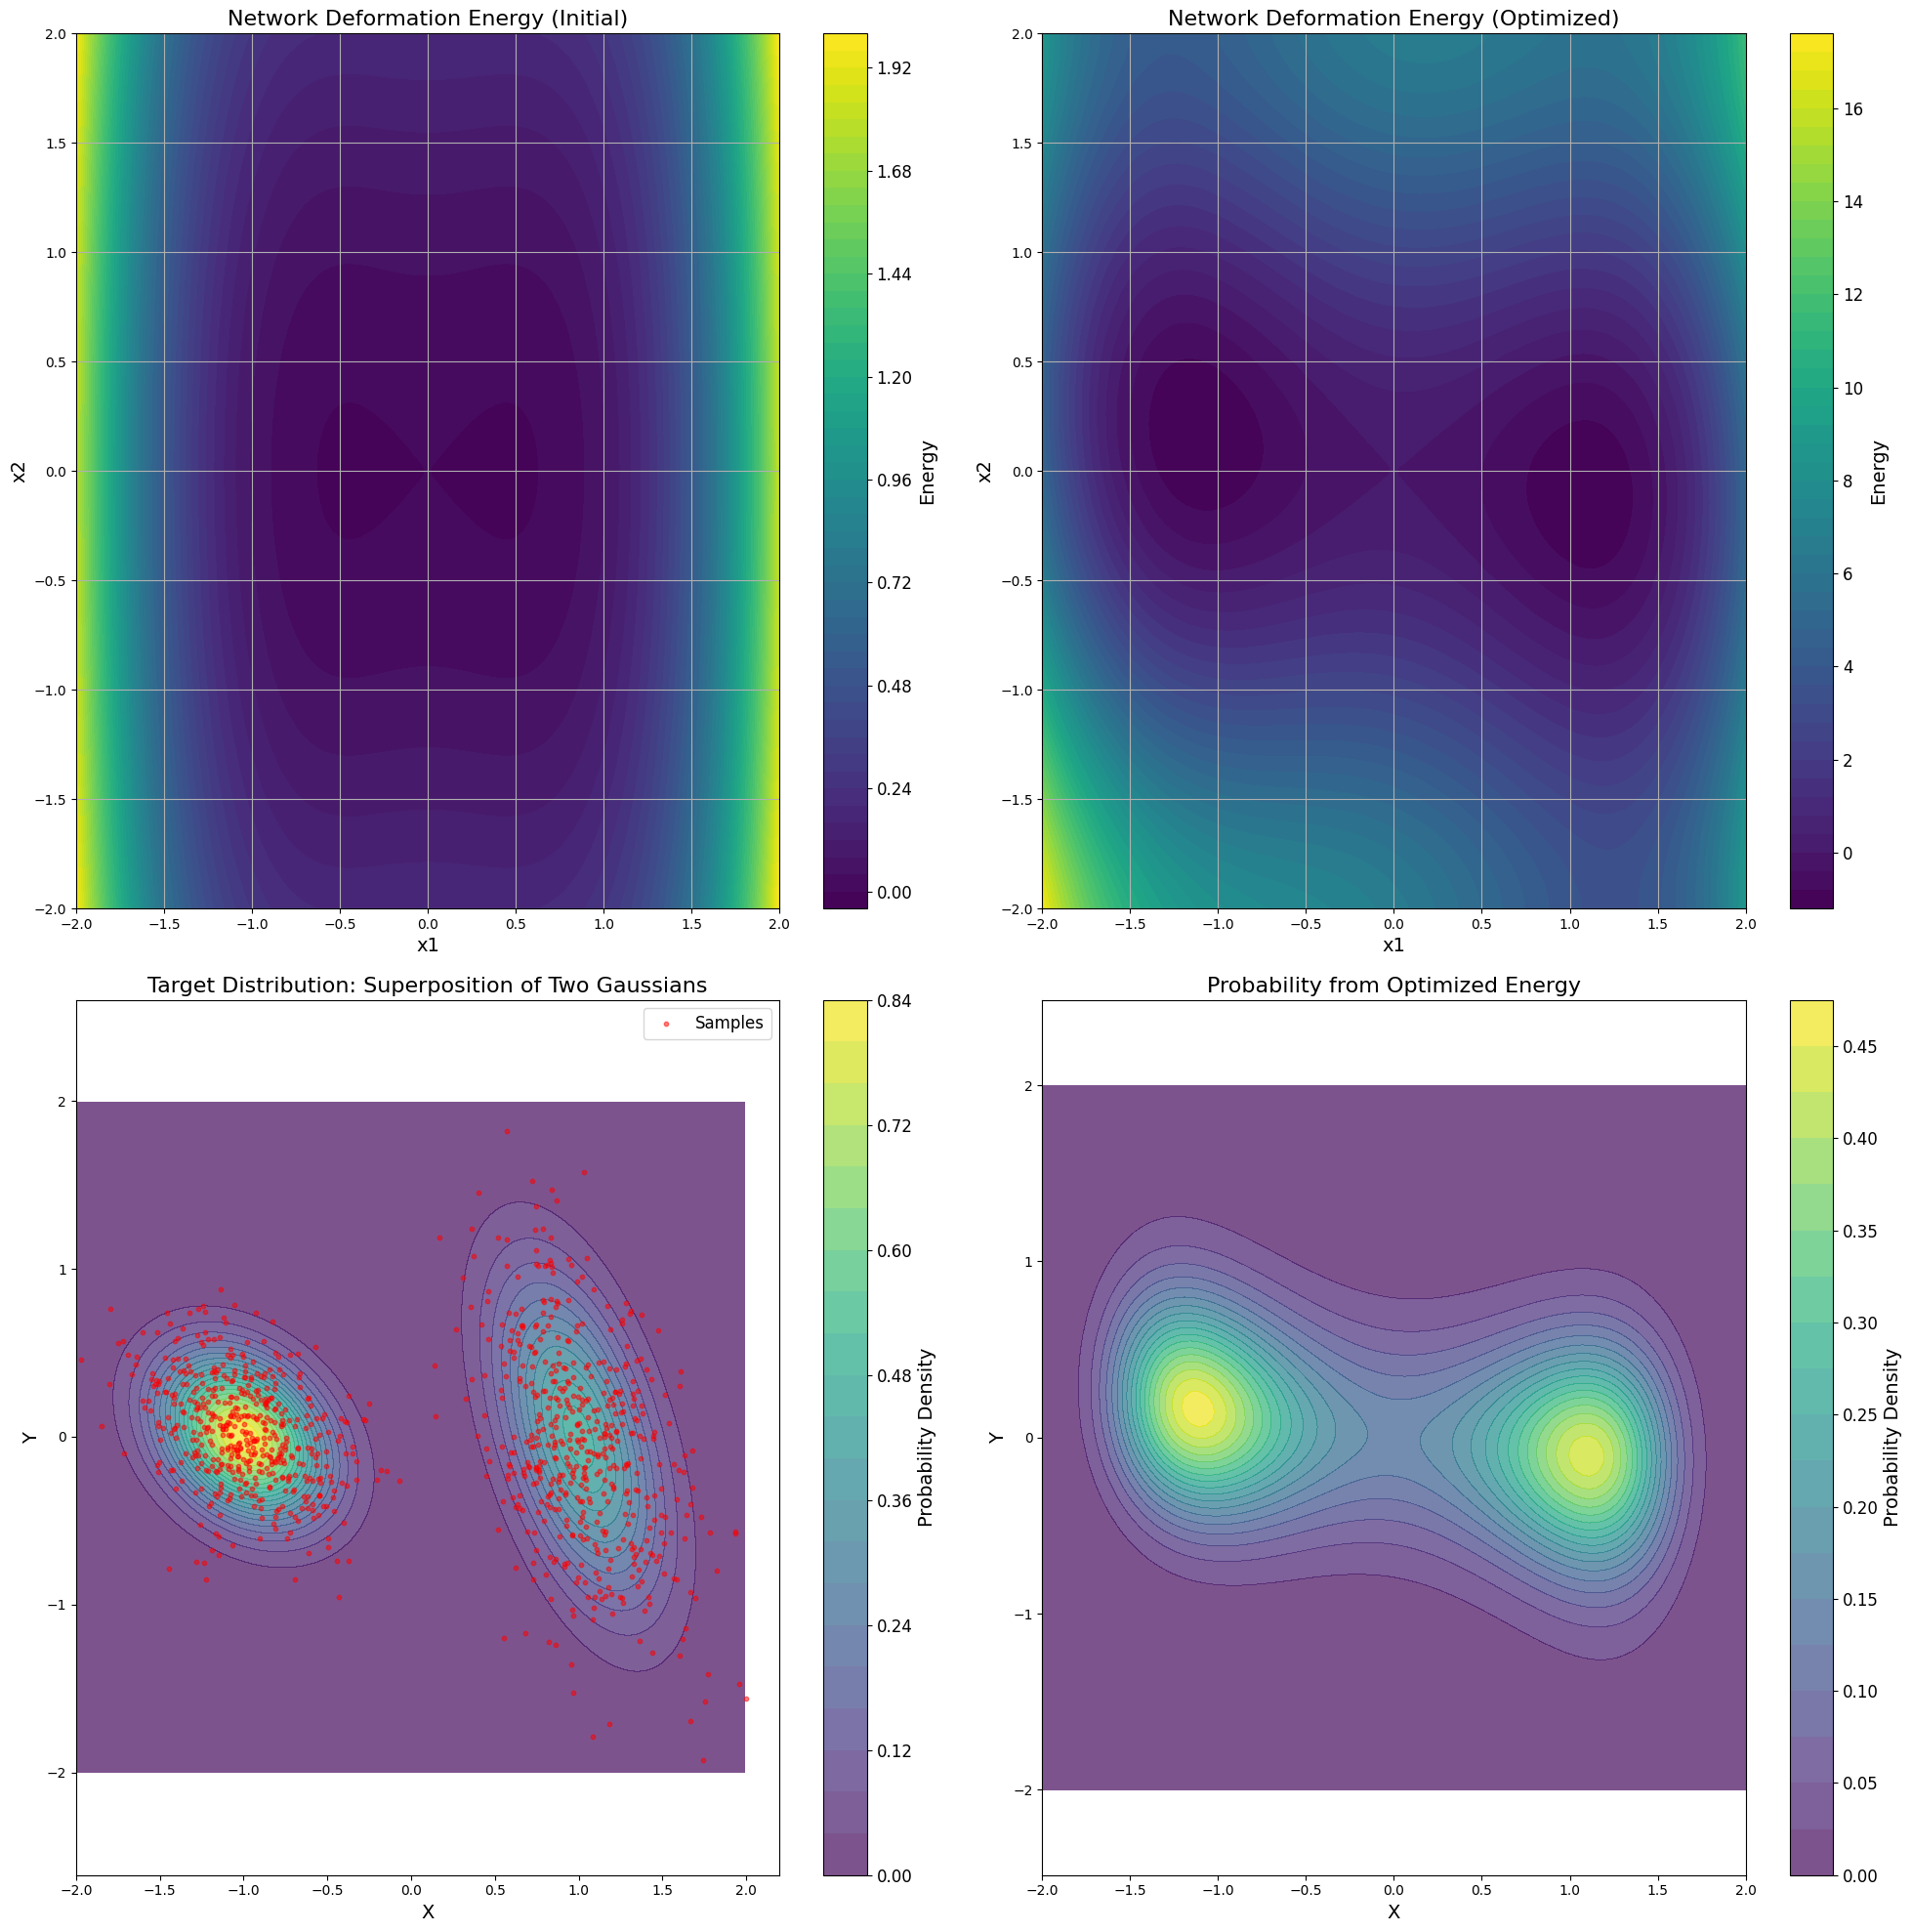

Original k_lin: [-0.1  0.1], k_duff: [0.5 0. ], c_lin: [0.], c_optomech: [0.]
Optimized k_lin: [-2.9142454  6.7197056], k_duff: [ 3.0385838 -1.3506347], c_lin: [-0.3625578], c_optomech: [-0.18113045]


In [10]:
# ... (previous code remains the same)

# Create 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

# Increase font size for all text elements
plt.rcParams.update({'font.size': 14})

# Plot original k energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
cbar1 = fig.colorbar(contour1, ax=ax1)
cbar1.set_label('Energy', fontsize=14)
ax1.set_title("Network Deformation Energy (Initial)", fontsize=16)
ax1.set_xlabel("x1", fontsize=14)
ax1.set_ylabel("x2", fontsize=14)
ax1.grid(True)

# Plot optimized k energy
contour2 = ax2.contourf(X1, X2, energy_values_optimized, levels=50, cmap='viridis')
cbar2 = fig.colorbar(contour2, ax=ax2)
cbar2.set_label('Energy', fontsize=14)
ax2.set_title("Network Deformation Energy (Optimized)", fontsize=16)
ax2.set_xlabel("x1", fontsize=14)
ax2.set_ylabel("x2", fontsize=14)
ax2.grid(True)

# Plot target distribution
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)
z = p1 * z1 + (1 - p1) * z2

contour3 = ax3.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
cbar3 = fig.colorbar(contour3, ax=ax3)
cbar3.set_label('Probability Density', fontsize=14)
ax3.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')
ax3.set_title('Target Distribution: Superposition of Two Gaussians', fontsize=16)
ax3.set_xlabel('X', fontsize=14)
ax3.set_ylabel('Y', fontsize=14)
ax3.legend(fontsize=12)
ax3.axis('equal')

# Plot probability from optimized energy
contour4 = ax4.contourf(X1, X2, prob_from_energy_normalized, levels=20, cmap='viridis', alpha=0.7)
cbar4 = fig.colorbar(contour4, ax=ax4)
cbar4.set_label('Probability Density', fontsize=14)
ax4.set_title('Probability from Optimized Energy', fontsize=16)
ax4.set_xlabel('X', fontsize=14)
ax4.set_ylabel('Y', fontsize=14)
ax4.axis('equal')

# Increase font size for colorbar labels
for cbar in [cbar1, cbar2, cbar3, cbar4]:
    cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

filename = convergence_filename.replace("_convergence.png", ".png")

# Save the figure to the results folder
plt.savefig(f'results/{folder_filename}/{filename}', dpi=300, bbox_inches='tight')

plt.show()


# Print k values for reference
print(f"Original k_lin: {k_lin}, k_duff: {k_duff}, c_lin: {c_lin}, c_optomech: {c_optomech}")
print(f"Optimized k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")